# M2 Evaluation Results — Visualization

This notebook generates the charts used in the blog post *"Synthetic vs Real Data: What Changed (and What Didn't) When Migrating a RAG System"*.

It produces three figures:
1. **Synthetic vs Real (Hybrid scenario)** — 5 DeepEval metrics compared between the April synthetic baseline and the July real-corpus run.
2. **Vector Only vs Hybrid (real corpus)** — 5 metrics compared between the two search strategies.
3. **Evaluation sample composition** — the 9 StackExchange communities represented in the 50 golden pairs used for the evaluation.

All metrics are **loaded from the evaluation logs** in `documentation/markdowns/2_post_migration_eval/logs/` — nothing is hardcoded. The charts are saved as PNG files in `documentation/markdowns/2_post_migration_eval/images/`.

In [12]:
MILESTONE_DIR = resolve_repo_path("documentation", "markdowns", "2_post_migration_eval")
LOGS_DIR = MILESTONE_DIR / "logs"
OUTPUT_DIR = MILESTONE_DIR / "images"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GOLDEN_PATH = resolve_repo_path("evaluation_notebooks", "goldens", "golden_se_200.json")
SYNTHETIC_LOG_PATH = LOGS_DIR / "hybrid_operational_results_050426.csv"

print(f"Logs:      {LOGS_DIR.resolve()}")
print(f"Images:    {OUTPUT_DIR.resolve()}")
print(f"Golden:    {GOLDEN_PATH.resolve()}")
print(f"Synthetic: {SYNTHETIC_LOG_PATH.resolve()}")

Logs:      /home/guillermo/Documentos/Courses/GenAI_E2_bootcamp/Tarea_2/documentation/markdowns/2_post_migration_eval/logs
Images:    /home/guillermo/Documentos/Courses/GenAI_E2_bootcamp/Tarea_2/documentation/markdowns/2_post_migration_eval/images
Golden:    /home/guillermo/Documentos/Courses/GenAI_E2_bootcamp/Tarea_2/evaluation_notebooks/goldens/golden_se_200.json
Synthetic: /home/guillermo/Documentos/Courses/GenAI_E2_bootcamp/Tarea_2/documentation/markdowns/2_post_migration_eval/logs/hybrid_operational_results_050426.csv


## Evaluation Data

All values in this notebook are computed from the logs, never hardcoded:

- **Real corpus (July 2026)**: per-question logs of the definitive run (2026-07-31) — 50 stratified pairs across 9 communities, DeepSeek V4 Flash generator + judge (OpenRouter), golden pairs excluded from the index. Search scope: `tickets_only`. Two scenarios: `baseline_vector_only` and `hybrid_no_rrf`.
- **Synthetic baseline (April 2026)**: 30 operational questions on the synthetic corpus, Llama 3.1 8B generator, Llama 4 Scout judge (Groq). Log (`hybrid_operational_results_050426.csv`) is kept in the same `logs/` folder as the July runs.
- **Sample composition**: derived from the golden file (`golden_se_200.json`) — the community of each evaluated pair is extracted from its `ticketId` prefix (e.g., `SE-ASKUBUNTU-...`).

Both runs used the same evaluation methodology: generate an answer with the LLM and compare it against the golden answer using DeepEval.

In [13]:
# Evaluation data — loaded from the logs, nothing hardcoded

METRIC_COLUMNS = [
    "correctness",
    "faithfulness",
    "answer_relevancy",
    "contextual_precision",
    "contextual_recall",
]
metrics = [
    "Correctness",
    "Faithfulness",
    "AnswerRelevancy",
    "ContextualPrecision",
    "ContextualRecall",
]

# --- Real corpus (July 2026), definitive run: one row per evaluated question (50) ---
vector_log = pd.read_csv(LOGS_DIR / "baseline_vector_only_golden_se_200_20260731_192818.csv")
hybrid_log = pd.read_csv(LOGS_DIR / "hybrid_no_rrf_golden_se_200_20260731_214733.csv")
assert len(vector_log) == 50 and len(hybrid_log) == 50, "expected 50 evaluated questions per scenario"

real_vector = (vector_log[METRIC_COLUMNS].mean() * 100).round(2).tolist()
real_hybrid_full = (hybrid_log[METRIC_COLUMNS].mean() * 100).round(2).tolist()

# --- Synthetic baseline (April 2026): 30 operational questions on the synthetic corpus ---
synthetic_log = pd.read_csv(SYNTHETIC_LOG_PATH)
synth_map = {
    "Correctness Score": "correctness",
    "Faithfulness Score": "faithfulness",
    "AnswerRelevancy Score": "answer_relevancy",
    "ContextualPrecision Score": "contextual_precision",
    "ContextualRecall Score": "contextual_recall",
}
synthetic_hybrid = (synthetic_log[list(synth_map)].mean() * 100).round(2).tolist()

# --- Cross-check: aggregates from the raw logs vs the official comparison CSV ---
# Note: the CSV was saved with the scenario code as the index (e.g. `baseline_vector_only`)
# and the human-readable label in the `scenario` column.
comparison = pd.read_csv(LOGS_DIR / "comparison_20260731_definitive.csv", index_col=0)
comparison[METRIC_COLUMNS] = comparison[METRIC_COLUMNS].apply(
    lambda col: col.astype(str).str.rstrip("%").astype(float)
)
official_vector = comparison.loc["baseline_vector_only", METRIC_COLUMNS].tolist()
official_hybrid = comparison.loc["hybrid_no_rrf", METRIC_COLUMNS].tolist()
np.testing.assert_allclose(real_vector, official_vector, atol=0.05)
np.testing.assert_allclose(real_hybrid_full, official_hybrid, atol=0.05)
print("Cross-check OK: raw-log aggregates match the official comparison CSV.")

# --- Sample composition: first 50 pairs of the shuffled golden file (community from ticketId prefix) ---
with open(GOLDEN_PATH, encoding="utf-8") as f:
    golden_pairs = json.load(f)
sample_counts = Counter(g["ticketId"].split("-")[1].lower() for g in golden_pairs[:50])
communities = [
    "superuser", "askubuntu", "apple", "android", "devops",
    "dba", "networkengineering", "serverfault", "security",
]
counts = [sample_counts[c] for c in communities]

df_comparison = pd.DataFrame(
    {
        "Metric": metrics,
        "Synthetic (April)": synthetic_hybrid,
        "Real (July)": real_hybrid_full,
    }
)

df_scenarios = pd.DataFrame(
    {
        "Metric": metrics,
        "Vector Only": real_vector,
        "Hybrid (BM25 + Vector)": real_hybrid_full,
    }
)

df_comparison

Cross-check OK: raw-log aggregates match the official comparison CSV.


,Metric,Synthetic (April),Real (July)
0,Correctness,19.33,25.80
1,Faithfulness,84.24,97.03
2,AnswerRelevancy,56.31,85.52
3,ContextualPrecision,11.19,7.99
4,ContextualRecall,11.67,5.71


## Chart 1 — Synthetic vs Real Corpus (Hybrid Scenario)

This grouped bar chart compares the five DeepEval metrics between the April synthetic baseline and the July real-corpus run, both using the Hybrid (BM25 + Vector) search strategy.

**Reading the chart**: Correctness, Faithfulness and AnswerRelevancy all improved after the migration (the blue bars are taller). ContextualPrecision and ContextualRecall decreased slightly — the retrieval stage remains the bottleneck regardless of the data source.


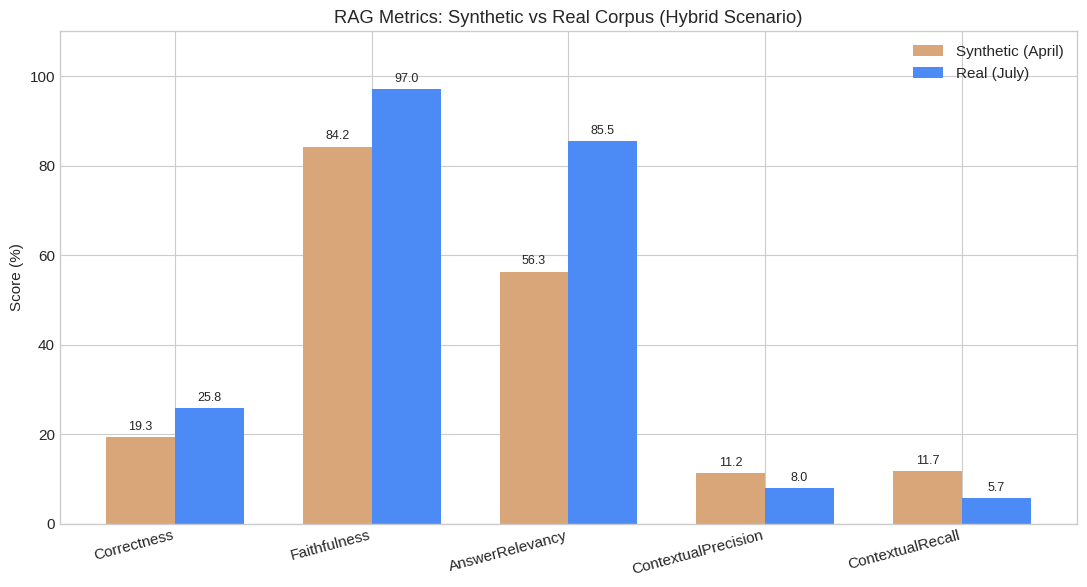

Saved: metrics_synthetic_vs_real.png


In [14]:
# Chart 1: Synthetic vs Real — grouped bar chart (Hybrid scenario)
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width / 2, synthetic_hybrid, width, label="Synthetic (April)", color=SYNTHETIC_COLOR)
bars2 = ax.bar(x + width / 2, real_hybrid_full, width, label="Real (July)", color=REAL_COLOR)

ax.set_ylabel("Score (%)")
ax.set_title("RAG Metrics: Synthetic vs Real Corpus (Hybrid Scenario)")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 110)

# Value labels on top of each bar
for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "metrics_synthetic_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metrics_synthetic_vs_real.png")

## Chart 2 — Vector Only vs Hybrid (Real Corpus)

This grouped bar chart compares the two search strategies evaluated on the real corpus: pure vector search and hybrid search (BM25 + Vector).

**Reading the chart**: generation metrics (Faithfulness, AnswerRelevancy) are high for both strategies — the generator works regardless of the retriever. But retrieval metrics (ContextualPrecision, ContextualRecall) drop to 0% with Vector Only: BM25 is what makes retrieval work at all in this system.


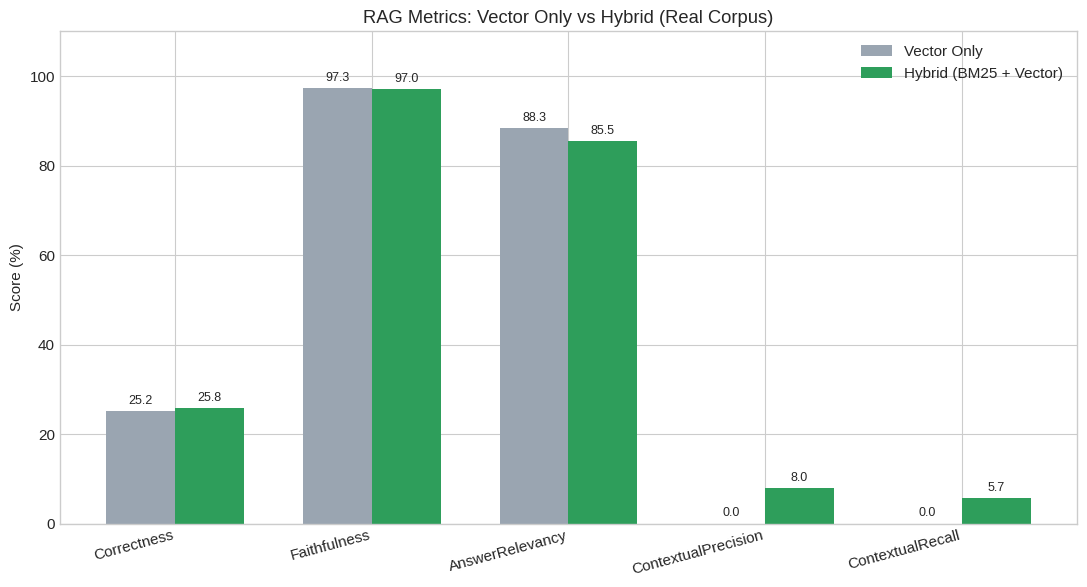

Saved: metrics_vector_vs_hybrid.png


In [15]:
# Chart 2: Vector Only vs Hybrid — grouped bar chart (real corpus)
fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width / 2, real_vector, width, label="Vector Only", color=VECTOR_COLOR)
bars2 = ax.bar(x + width / 2, real_hybrid_full, width, label="Hybrid (BM25 + Vector)", color=HYBRID_COLOR)

ax.set_ylabel("Score (%)")
ax.set_title("RAG Metrics: Vector Only vs Hybrid (Real Corpus)")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 110)

for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "metrics_vector_vs_hybrid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metrics_vector_vs_hybrid.png")


## Chart 3 — Evaluation Sample Composition

This donut chart shows the community distribution of the 50 golden pairs used for the evaluation. The pairs were sampled with stratified quotas (proportional to each community's relevance for L1 IT support) and then shuffled with a fixed seed, so the first 50 pairs of the golden file are representative of all 9 communities.

**Reading the chart**: superuser and askubuntu dominate (the largest communities in the corpus), while smaller communities like devops and networkengineering still have guaranteed representation thanks to the stratification.


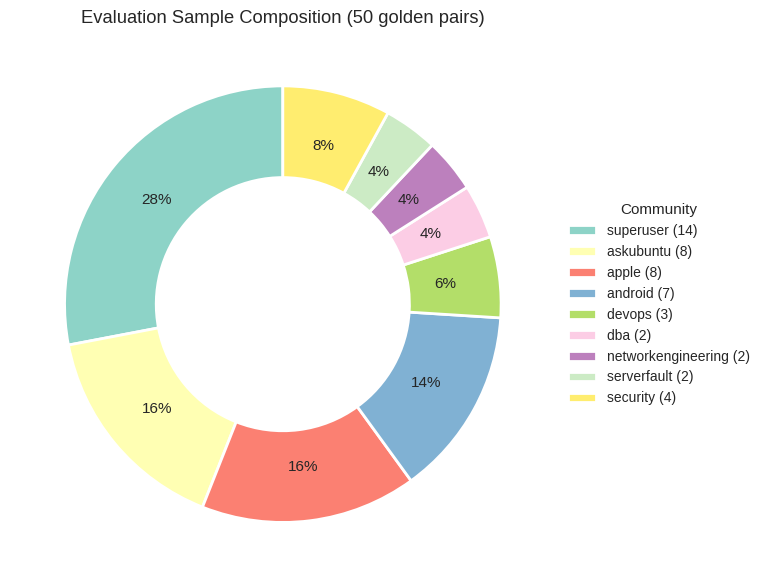

Saved: sample_community_composition.png


In [16]:
# Chart 3: Evaluation sample composition — donut chart
colors = plt.cm.Set3(np.linspace(0, 1, len(communities)))

fig, ax = plt.subplots(figsize=(9, 6))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=None,
    autopct=lambda pct: f"{pct:.0f}%",
    startangle=90,
    colors=colors,
    pctdistance=0.75,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
)

ax.legend(
    wedges,
    [f"{c} ({n})" for c, n in zip(communities, counts)],
    title="Community",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10,
)

ax.set_title("Evaluation Sample Composition (50 golden pairs)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_community_composition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sample_community_composition.png")


## Export Summary

The three charts above were saved as PNG files in `documentation/markdowns/2_post_migration_eval/images/`:

| File | Content |
|------|---------|
| `metrics_synthetic_vs_real.png` | Synthetic (April) vs Real (July) — Hybrid scenario, 5 metrics |
| `metrics_vector_vs_hybrid.png` | Vector Only vs Hybrid — real corpus, 5 metrics |
| `sample_community_composition.png` | Community distribution of the 50 evaluated pairs |

These images are referenced from the blog posts (`post_migration_eval_es.md` / `post_migration_eval_en.md`) with standard `![alt](images/...)` syntax.